In [23]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns


In [25]:
# Load orthogonalized VAD vectors
vad_vectors = pd.read_csv('../Datasets/orthogonalized_vad_vectors.csv')
baseline_scores = pd.read_csv('../Datasets/baseline_vad_scores.csv')

print("VAD Vectors shape:", vad_vectors.shape)
print("Baseline scores shape:", baseline_scores.shape)
print("\nModels available:", vad_vectors['model'].unique())


VAD Vectors shape: (12, 770)
Baseline scores shape: (159, 4)

Models available: ['BERT' 'RoBERTa' 'NeoBERT' 'ModernBERT']


In [27]:
# Model mapping
models = {
    'BERT': 'test_embeddings_bert.csv',
    'RoBERTa': 'test_embeddings_roberta.csv',
    'ModernBERT': 'test_embeddings_modernbert.csv',
    'NeoBERT': 'test_embeddings_neobert.csv'
}

def calculate_vad_scores(model_name, embeddings_file):
    # Load test embeddings
    test_embeddings = pd.read_csv(f'../Datasets/Embeddings/{embeddings_file}')
    
    # Extract embedding columns
    emb_cols = [col for col in test_embeddings.columns if col.startswith('emb_')]
    embeddings_matrix = test_embeddings[emb_cols].values
    
    # Get VAD vectors for this model
    model_vad = vad_vectors[vad_vectors['model'] == model_name]
    
    # Extract dimension columns
    dim_cols = [col for col in model_vad.columns if col.startswith('dim_')]
    
    # Get V, A, D vectors
    v_vector = model_vad[model_vad['vector_name'] == 'dir_V'][dim_cols].values[0]
    a_vector = model_vad[model_vad['vector_name'] == 'dir_A'][dim_cols].values[0]
    d_vector = model_vad[model_vad['vector_name'] == 'dir_D'][dim_cols].values[0]
    
    # Calculate cosine similarities
    valence_scores = cosine_similarity(embeddings_matrix, v_vector.reshape(1, -1)).flatten()
    arousal_scores = cosine_similarity(embeddings_matrix, a_vector.reshape(1, -1)).flatten()
    dominance_scores = cosine_similarity(embeddings_matrix, d_vector.reshape(1, -1)).flatten()
    
    # Create results dataframe
    results = pd.DataFrame({
        'sentence': test_embeddings['Sentence'],
        'valence': valence_scores,
        'arousal': arousal_scores,
        'dominance': dominance_scores
    })
    
    return results

print("Function defined")


Function defined


In [29]:
# Calculate VAD scores for all models
all_results = {}

for model_name, embeddings_file in models.items():
    print(f"Processing {model_name}...")
    results = calculate_vad_scores(model_name, embeddings_file)
    all_results[model_name] = results
    print(f"  {model_name} completed. Shape: {results.shape}")

print("\nAll models processed")


Processing BERT...
  BERT completed. Shape: (159, 4)
Processing RoBERTa...
  RoBERTa completed. Shape: (159, 4)
Processing ModernBERT...
  ModernBERT completed. Shape: (159, 4)
Processing NeoBERT...
  NeoBERT completed. Shape: (159, 4)

All models processed


In [31]:
# Display sample results
print("Sample results from BERT:")
print(all_results['BERT'].head())
print("\nBaseline scores sample:")
print(baseline_scores.head())


Sample results from BERT:
                                            sentence   valence   arousal  \
0  OMG, just watched that new Marvel flick, total...  0.045992 -0.035040   
1  Life's gr8, scored tickets to Taylor Swift con...  0.005305 -0.019424   
2  Yo, promotion at work finally, feelin like a b...  0.087908 -0.103206   
3  Chillin with fam on vacation, beach vibes, tot...  0.021778 -0.214440   
4  Quiet prayer time, feelin blessed and peaceful...  0.075278 -0.258281   

   dominance  
0  -0.048130  
1  -0.020002  
2   0.000974  
3   0.018507  
4  -0.000337  

Baseline scores sample:
                                            sentence  valence  arousal  \
0  OMG, just watched that new Marvel flick, total...   0.3003   0.0685   
1  Life's gr8, scored tickets to Taylor Swift con...   0.5294   0.3266   
2  Yo, promotion at work finally, feelin like a b...   0.3280   0.0655   
3  Chillin with fam on vacation, beach vibes, tot...   0.3707  -0.1517   
4  Quiet prayer time, feelin ble

In [33]:
# Calculate evaluation metrics
def evaluate_predictions(predicted, baseline, dimensions=['valence', 'arousal', 'dominance']):
    results = {}
    
    for dim in dimensions:
        pred = predicted[dim].values
        true = baseline[dim].values
        
        # Correlation metrics
        pearson_corr, pearson_p = pearsonr(pred, true)
        spearman_corr, spearman_p = spearmanr(pred, true)
        
        # Error metrics
        mae = mean_absolute_error(true, pred)
        mse = mean_squared_error(true, pred)
        rmse = np.sqrt(mse)
        
        results[dim] = {
            'pearson_r': pearson_corr,
            'pearson_p': pearson_p,
            'spearman_r': spearman_corr,
            'spearman_p': spearman_p,
            'mae': mae,
            'mse': mse,
            'rmse': rmse
        }
    
    return results

# Evaluate all models
evaluation_results = {}

for model_name, predictions in all_results.items():
    print(f"\nEvaluating {model_name}:")
    eval_metrics = evaluate_predictions(predictions, baseline_scores)
    evaluation_results[model_name] = eval_metrics
    
    for dim, metrics in eval_metrics.items():
        print(f"  {dim.upper()}:")
        print(f"    Pearson r: {metrics['pearson_r']:.4f} (p={metrics['pearson_p']:.4e})")
        print(f"    Spearman r: {metrics['spearman_r']:.4f} (p={metrics['spearman_p']:.4e})")
        print(f"    MAE: {metrics['mae']:.4f}")
        print(f"    RMSE: {metrics['rmse']:.4f}")



Evaluating BERT:
  VALENCE:
    Pearson r: 0.7244 (p=3.7844e-27)
    Spearman r: 0.6954 (p=2.6745e-24)
    MAE: 0.2218
    RMSE: 0.2726
  AROUSAL:
    Pearson r: 0.5389 (p=2.3358e-13)
    Spearman r: 0.5573 (p=2.3510e-14)
    MAE: 0.2627
    RMSE: 0.3168
  DOMINANCE:
    Pearson r: 0.1049 (p=1.8831e-01)
    Spearman r: 0.0879 (p=2.7036e-01)
    MAE: 0.1611
    RMSE: 0.2011

Evaluating RoBERTa:
  VALENCE:
    Pearson r: 0.7439 (p=2.7981e-29)
    Spearman r: 0.7438 (p=2.9044e-29)
    MAE: 0.2637
    RMSE: 0.3131
  AROUSAL:
    Pearson r: 0.5939 (p=1.5647e-16)
    Spearman r: 0.6284 (p=7.4437e-19)
    MAE: 0.2624
    RMSE: 0.3193
  DOMINANCE:
    Pearson r: 0.3541 (p=4.6618e-06)
    Spearman r: 0.4122 (p=6.7375e-08)
    MAE: 0.3732
    RMSE: 0.4109

Evaluating ModernBERT:
  VALENCE:
    Pearson r: 0.2646 (p=7.5122e-04)
    Spearman r: 0.2637 (p=7.8363e-04)
    MAE: 0.2547
    RMSE: 0.3070
  AROUSAL:
    Pearson r: 0.2499 (p=1.4920e-03)
    Spearman r: 0.2556 (p=1.1490e-03)
    MAE: 0.205

In [35]:
# Create summary dataframe
summary_data = []

for model_name, metrics_dict in evaluation_results.items():
    for dim, metrics in metrics_dict.items():
        summary_data.append({
            'Model': model_name,
            'Dimension': dim,
            'Pearson_r': metrics['pearson_r'],
            'Spearman_r': metrics['spearman_r'],
            'MAE': metrics['mae'],
            'RMSE': metrics['rmse']
        })

summary_df = pd.DataFrame(summary_data)
print("\nSummary of Results:")
print(summary_df.to_string(index=False))



Summary of Results:
     Model Dimension  Pearson_r  Spearman_r      MAE     RMSE
      BERT   valence   0.724408    0.695417 0.221754 0.272624
      BERT   arousal   0.538916    0.557316 0.262720 0.316794
      BERT dominance   0.104874    0.087937 0.161127 0.201088
   RoBERTa   valence   0.743921    0.743779 0.263691 0.313115
   RoBERTa   arousal   0.593918    0.628447 0.262421 0.319313
   RoBERTa dominance   0.354129    0.412160 0.373221 0.410940
ModernBERT   valence   0.264580    0.263698 0.254736 0.306991
ModernBERT   arousal   0.249856    0.255562 0.205341 0.253708
ModernBERT dominance  -0.238281   -0.218108 0.173576 0.217891
   NeoBERT   valence   0.716921    0.721022 0.262288 0.312641
   NeoBERT   arousal   0.494611    0.529150 0.193890 0.239460
   NeoBERT dominance   0.067924    0.148822 0.173747 0.216755


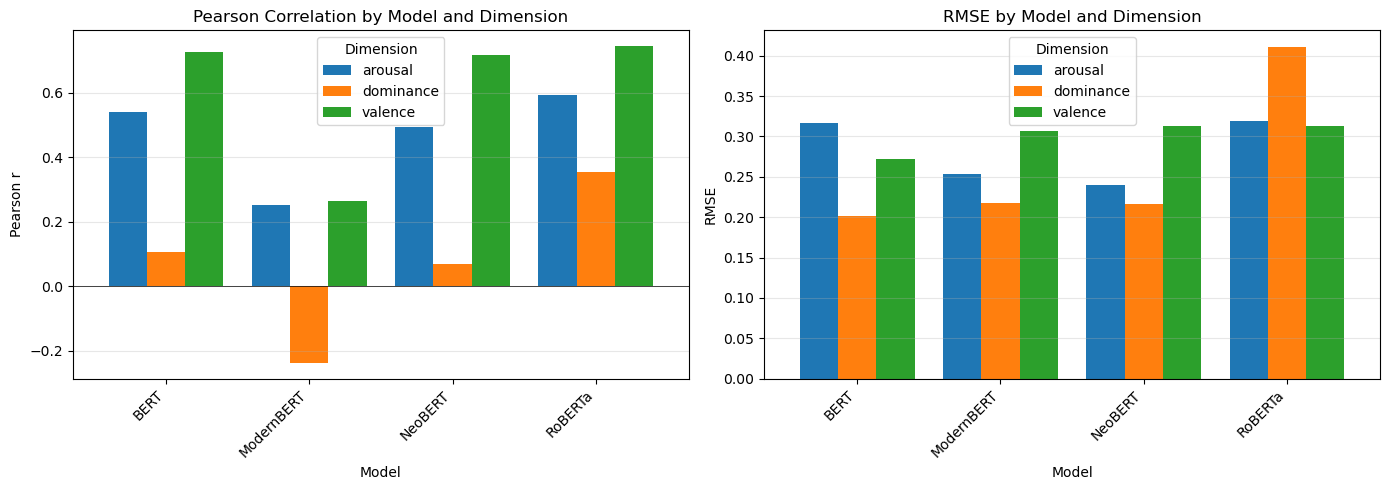

In [37]:
# Visualization: Correlation comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pearson correlation
pearson_pivot = summary_df.pivot(index='Model', columns='Dimension', values='Pearson_r')
pearson_pivot.plot(kind='bar', ax=axes[0], width=0.8)
axes[0].set_title('Pearson Correlation by Model and Dimension')
axes[0].set_ylabel('Pearson r')
axes[0].set_xlabel('Model')
axes[0].legend(title='Dimension')
axes[0].axhline(y=0, color='k', linestyle='-', linewidth=0.5)
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')

# RMSE
rmse_pivot = summary_df.pivot(index='Model', columns='Dimension', values='RMSE')
rmse_pivot.plot(kind='bar', ax=axes[1], width=0.8)
axes[1].set_title('RMSE by Model and Dimension')
axes[1].set_ylabel('RMSE')
axes[1].set_xlabel('Model')
axes[1].legend(title='Dimension')
axes[1].grid(axis='y', alpha=0.3)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()


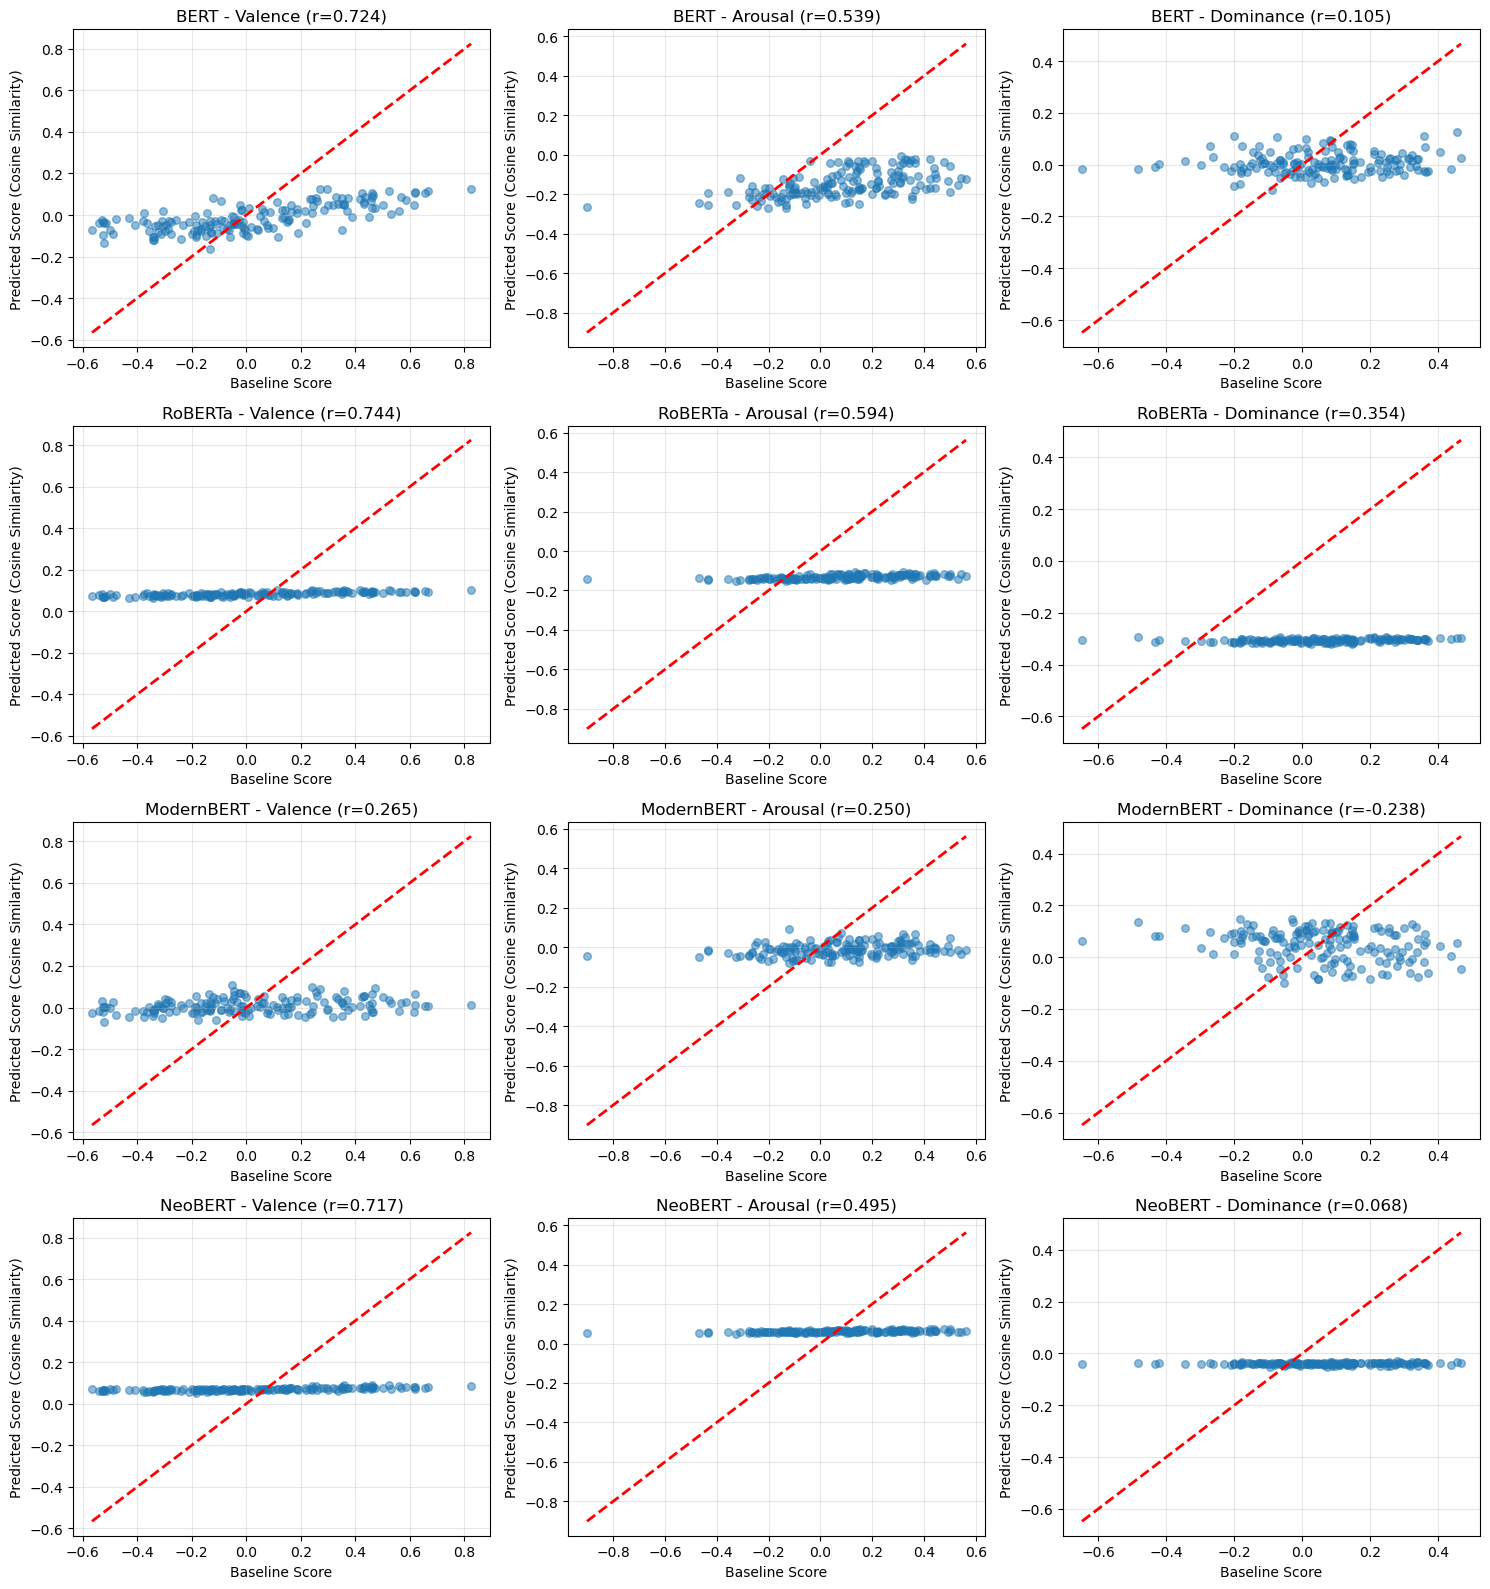

In [39]:
# Scatter plots: Predicted vs Baseline for each model
fig, axes = plt.subplots(len(models), 3, figsize=(15, 4*len(models)))

dimensions = ['valence', 'arousal', 'dominance']

for i, (model_name, predictions) in enumerate(all_results.items()):
    for j, dim in enumerate(dimensions):
        ax = axes[i, j] if len(models) > 1 else axes[j]
        
        pred = predictions[dim].values
        true = baseline_scores[dim].values
        
        ax.scatter(true, pred, alpha=0.5, s=30)
        ax.plot([true.min(), true.max()], [true.min(), true.max()], 'r--', lw=2)
        
        # Add correlation to title
        pearson_r = evaluation_results[model_name][dim]['pearson_r']
        ax.set_title(f'{model_name} - {dim.capitalize()} (r={pearson_r:.3f})')
        ax.set_xlabel('Baseline Score')
        ax.set_ylabel('Predicted Score (Cosine Similarity)')
        ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


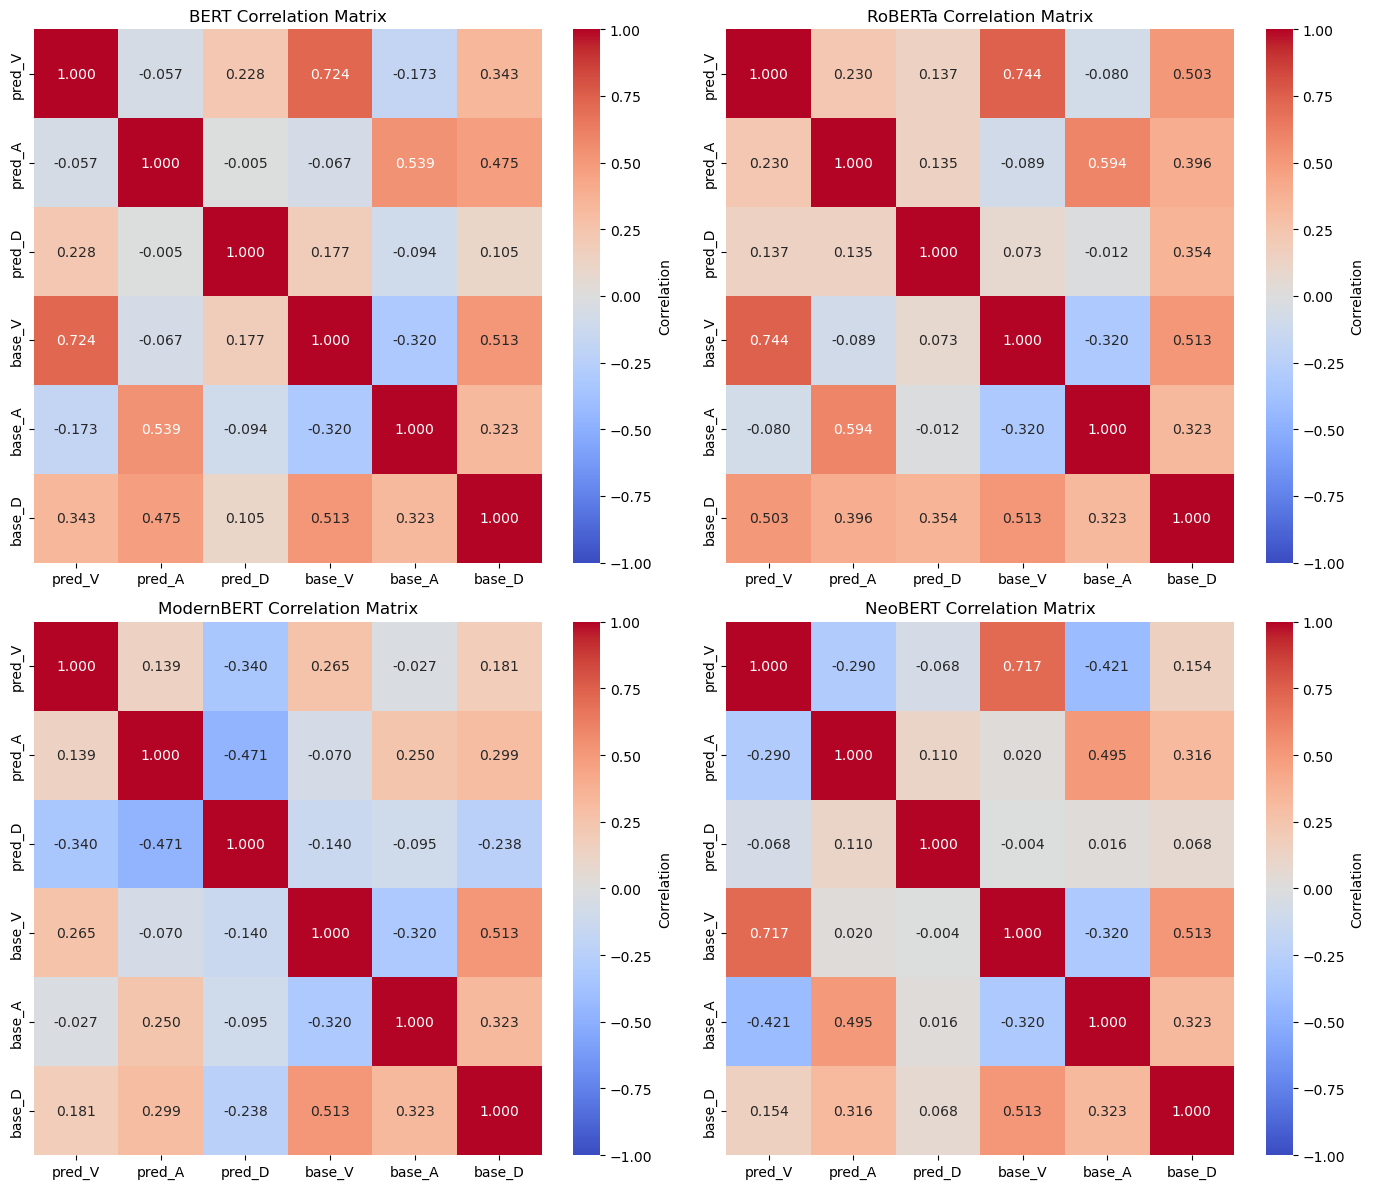

In [41]:
# Heatmap: Correlation matrix for all models
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, (model_name, predictions) in enumerate(all_results.items()):
    # Combine predicted and baseline scores
    combined = pd.DataFrame({
        'pred_V': predictions['valence'].values,
        'pred_A': predictions['arousal'].values,
        'pred_D': predictions['dominance'].values,
        'base_V': baseline_scores['valence'].values,
        'base_A': baseline_scores['arousal'].values,
        'base_D': baseline_scores['dominance'].values
    })
    
    corr_matrix = combined.corr()
    
    sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', 
                center=0, vmin=-1, vmax=1, ax=axes[idx],
                cbar_kws={'label': 'Correlation'})
    axes[idx].set_title(f'{model_name} Correlation Matrix')

plt.tight_layout()
plt.show()


In [43]:
# Save results to CSV
summary_df.to_csv('../Datasets/cosine_similarity_evaluation_summary.csv', index=False)
print("Summary saved to: Datasets/cosine_similarity_evaluation_summary.csv")

# Save detailed predictions for each model
for model_name, predictions in all_results.items():
    # Add baseline scores for comparison
    predictions['baseline_valence'] = baseline_scores['valence'].values
    predictions['baseline_arousal'] = baseline_scores['arousal'].values
    predictions['baseline_dominance'] = baseline_scores['dominance'].values
    
    filename = f'../Datasets/cosine_similarity_predictions_{model_name.lower()}.csv'
    predictions.to_csv(filename, index=False)
    print(f"Predictions saved to: {filename}")

print("\nAll results saved successfully")


Summary saved to: Datasets/cosine_similarity_evaluation_summary.csv
Predictions saved to: ../Datasets/cosine_similarity_predictions_bert.csv
Predictions saved to: ../Datasets/cosine_similarity_predictions_roberta.csv
Predictions saved to: ../Datasets/cosine_similarity_predictions_modernbert.csv
Predictions saved to: ../Datasets/cosine_similarity_predictions_neobert.csv

All results saved successfully


In [45]:
# Print best performing model for each dimension
print("\nBest Performing Models:")
for dim in ['valence', 'arousal', 'dominance']:
    dim_data = summary_df[summary_df['Dimension'] == dim]
    
    best_pearson = dim_data.loc[dim_data['Pearson_r'].idxmax()]
    best_rmse = dim_data.loc[dim_data['RMSE'].idxmin()]
    
    print(f"\n{dim.upper()}:")
    print(f"  Highest Pearson r: {best_pearson['Model']} (r={best_pearson['Pearson_r']:.4f})")
    print(f"  Lowest RMSE: {best_rmse['Model']} (RMSE={best_rmse['RMSE']:.4f})")



Best Performing Models:

VALENCE:
  Highest Pearson r: RoBERTa (r=0.7439)
  Lowest RMSE: BERT (RMSE=0.2726)

AROUSAL:
  Highest Pearson r: RoBERTa (r=0.5939)
  Lowest RMSE: NeoBERT (RMSE=0.2395)

DOMINANCE:
  Highest Pearson r: RoBERTa (r=0.3541)
  Lowest RMSE: BERT (RMSE=0.2011)
